<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/Live_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

w = np.array([0.6, 0.6])
theta = -0.2
eta = 0.5

for _ in range(100):
  erro_total = 0

  for i in range(4):
    u = x[i] @ w
    y_prime = 1 if u >= theta else 0
    erro = y[i] - y_prime

    if erro != 0:
      w = w + eta * erro * x[i]
      theta = theta - eta * erro
      erro_total += 1

  if erro_total == 0:
    break
else:
  raise("Esse padrão não é linearmente separável!!!")


TypeError: exceptions must derive from BaseException

In [ ]:
w, theta

(array([-0.4,  0.1]), np.float64(-0.19999999999999996))

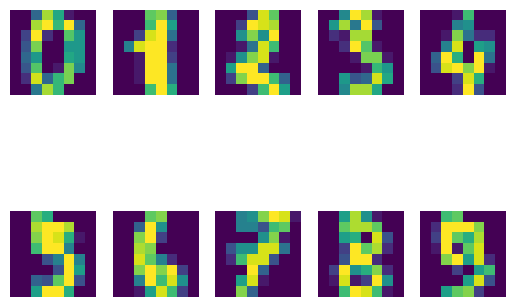

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt

digits = datasets.load_digits()

fig, axes = plt.subplots(2, 5)

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i])
    ax.axis('off')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

x, y = digits.data, digits.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x, y_onehot)
m = len(y)

In [ ]:
y[11], y_onehot[11]

(array([1]), array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [ ]:
x_train.shape

(1347, 64)

In [ ]:
import numpy as np

np.random.randn(1)

array([-1.36486359])

In [ ]:
n_1 = x_train.shape[1]
n_2 = 64
n_3 = 10

W2 = np.random.randn(n_2, n_1) * 0.1
b2 = np.zeros((n_2, 1))
W3 = np.random.rand(n_3, n_2) * 0.1
b3 = np.zeros((n_3, 1))

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

In [ ]:
def forward(W2, b2, W3, b3, x):
  z2 = W2 @ x.T + b2
  a2 = sigmoid(z2)

  z3 = W3 @ a2 + b3
  a3 = softmax(z3)

  return a3, a2

In [ ]:
y_prime, _ = forward(W2, b2, W3, b3, x_train)
y_prime.T[0]

array([0.08261604, 0.10918045, 0.11727234, 0.08085521, 0.09646704,
       0.11468783, 0.10253075, 0.07954724, 0.11115308, 0.10569001])

In [ ]:
def cross_entropy_loss(y_prime, y):
  return -np.sum(y*np.log(y_prime))/m

cross_entropy_loss(y_prime, y_train.T)

np.float64(1.7362849494530506)

In [ ]:
def sigmoid_prime(x):
  s = sigmoid(x)
  return s * (1 - s)

epochs = 500
eta = 0.2

W2 = np.random.randn(n_2, n_1) * 0.1
b2 = np.zeros((n_2, 1))
W3 = np.random.rand(n_3, n_2) * 0.1
b3 = np.zeros((n_3, 1))

J_history = []
for epoch in range(epochs):
  z2 = W2 @ x_train.T + b2
  a2 = sigmoid(z2)

  z3 = W3 @ a2 + b3
  a3 = softmax(z3)

  delta3 = a3 - y_train.T
  delta2 = (W3.T @ delta3) * sigmoid_prime(z2)

  dw3 = delta3 @ a2.T / m
  dw2 = delta2 @ x_train / m
  db3 = np.sum(delta3, axis=1, keepdims=True) / m
  db2 = np.sum(delta2, axis=1, keepdims=True) / m

  W3 -= eta * dw3
  W2 -= eta * dw2
  b3 -= eta * db3
  b2 -= eta * db2

  J_history.append(cross_entropy_loss(a3, y_train.T))

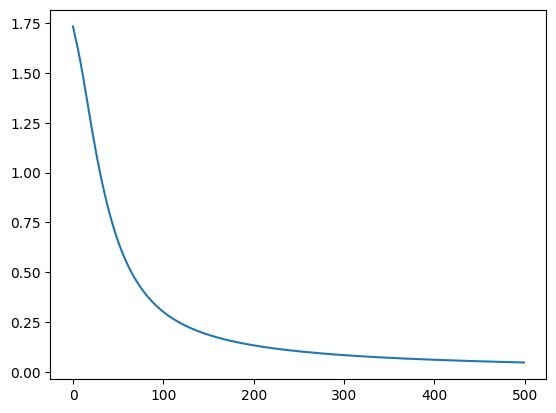

In [ ]:
import matplotlib.pyplot as plt

plt.plot(J_history)

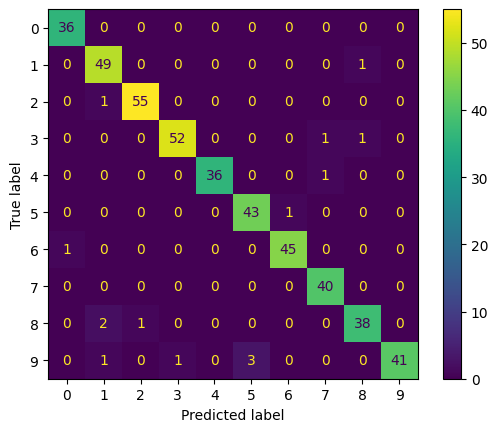

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = np.argmax(forward(W2, b2, W3, b3, x_test)[0], axis=0)
y_true = np.argmax(y_test, axis=1)

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)